In [32]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from simulations.src import *
manifold_type = 'S2'
params_files = sorted(f for f in os.listdir('cluster/data/' + manifold_type))
print(params_files)

['1772805130.9265583', '1772991981.347479', '1772996441.151306']


-----

In [33]:
ID = params_files[-1]; print(ID)

results_ocv = pd.read_csv(
    f'cluster/data/{manifold_type}/{ID}/rate_ocv.csv',
    converters={'cv_Ms_star': parse_np_array,  'cv_rhos_star': parse_np_array}
)
results_mc = pd.read_csv(f'cluster/data/{manifold_type}/{ID}/rate_mc.csv')
params = pickle.load(open(f'cluster/data/{manifold_type}/{ID}/rate_params.csv', 'rb'))

1772996441.151306


In [34]:
display(params)

{'ID': 1772996441.151306,
 'manifold_type': 'S2',
 'n_samples_ls': [100, 500, 1000, 2500, 5000, 7500, 10000],
 'M_grid': array([1, 2, 3, 4, 5, 6, 7, 8]),
 'rho_grid': [0.002, 0.004, 0.006, 0.008, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1],
 'sigma2': 0.1,
 'test_size': 1000,
 'num_oracle_samples': 10000,
 'NMC': 50,
 'G_names': ['uniform', '1-modal', '4-modal', 'equator'],
 'G_params': [None,
  {'tau2': 0.05, 'num_modes': 1},
  {'tau2': 0.01, 'num_modes': 4},
  {'tau2': 0.001}]}

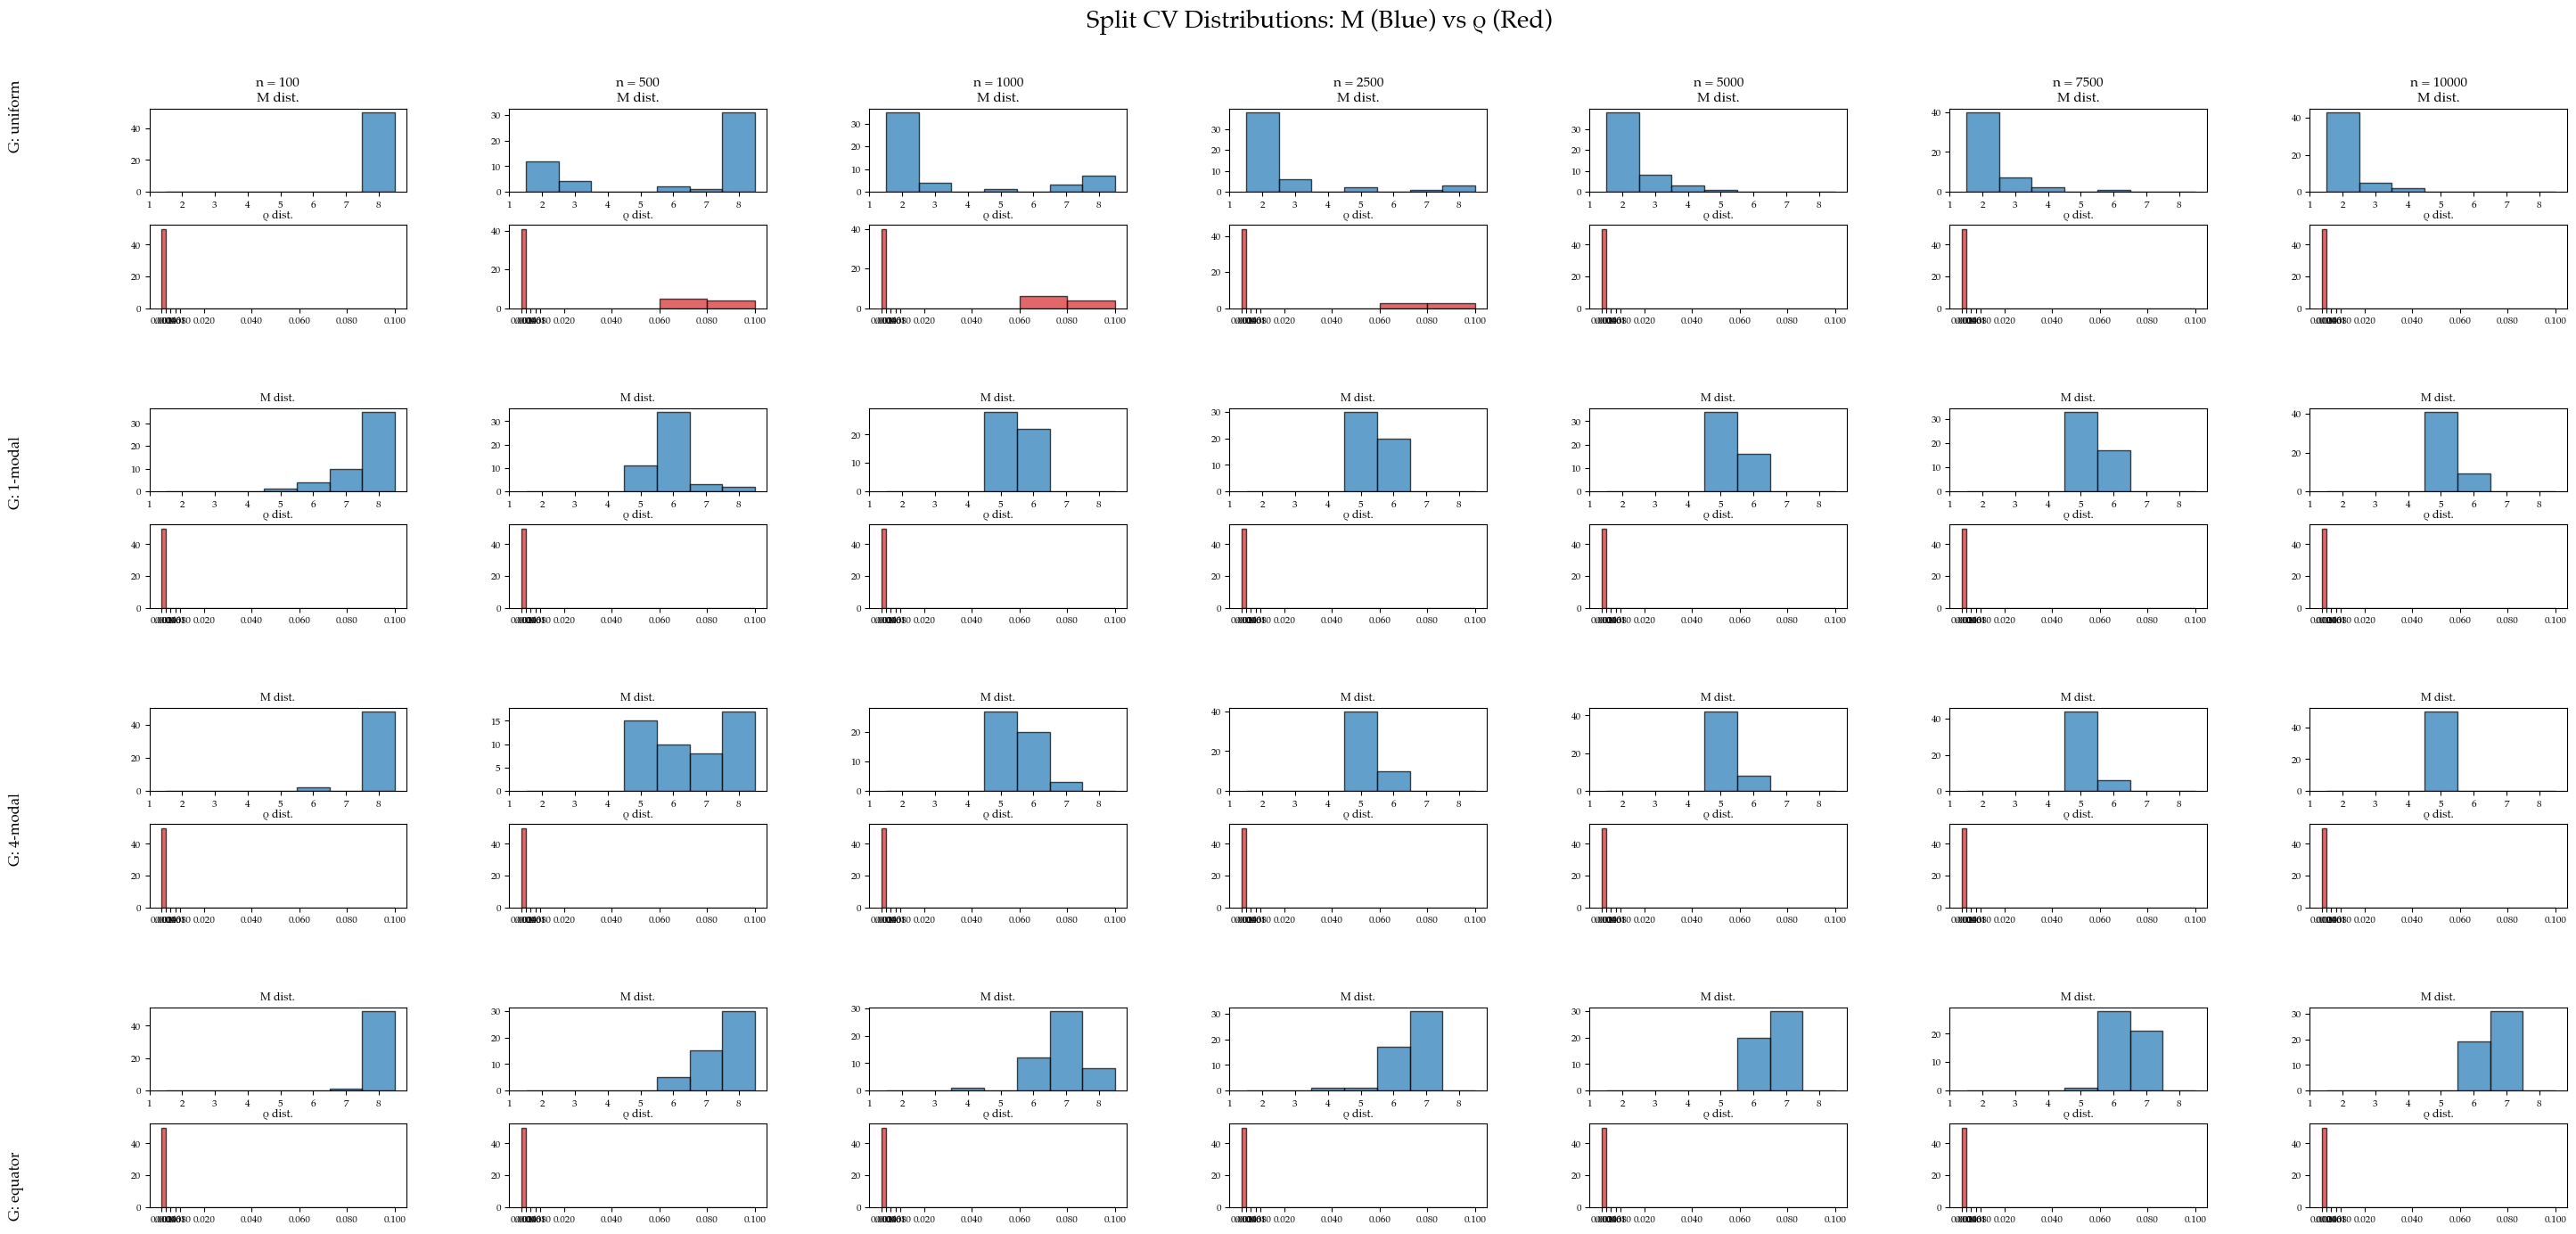

In [35]:
plot_cv_distributions_split(results_ocv, params)

In [38]:
extselected_Mrho = {}
for Gname in params['G_names']:
    n_arr = np.asarray(params['n_samples_ls'], dtype=int)
    if False:
        # original (continuous) rules
        rho_raw =  .5*(n_arr ** (-1/5))
        M_raw = np.log(n_arr) - 1
        # nearest grid points
        rho_snap =  params['rho_grid'][np.argmin(np.abs(rho_raw[:, None] -  params['rho_grid'][None, :]), axis=1)]
        M_snap = params['M_grid'][np.argmin(np.abs(M_raw[:, None] - params['M_grid'][None, :]), axis=1)].astype(int)
    rho_snap =  [0.002]*len(n_arr)#.5*(n_arr ** (-1/5))
    M_snap = np.log(.55*n_arr).astype(int)#[4,5,6,6,7,8,8]#np.log(n_arr) - 1
    extselected_Mrho[Gname] = {"rho": rho_snap, "M": M_snap}

In [39]:
plot_mcratesims_interactive(manifold_type, results_mc, results_ocv, params, extselected_Mrho )

Output()

----

In [18]:
# print(results_mc.rho.unique())
# print(results_mc.M.unique())
# M = 5; rho = 0.004
# plot_mcratesims(manifold_type, results_mc, M, rho, params)

-----

-----

-----